# LEVEL 2 TASK 1.  HOUSE PRICE ANALYSIS
## STEP 1: IMPORTATION OF LIBRARIES

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


### Importation of Libraries

The required Python libraries were imported to support data manipulation, statistical analysis, visualization, regression modelling, model evaluation, feature scaling, and K-Means clustering.

**Libraries imported:**

- **Pandas:** Data loading, manipulation, and analysis.
- **NumPy:** Numerical computations and mathematical operations.
- **Matplotlib:** Data visualization.
- **Scikit-learn:** Machine-learning tasks including train-test splitting, feature scaling, linear regression, model evaluation, and K-Means clustering.
- **Warnings:** Used to suppress non-critical warning messages during analysis.

**Observation:**

All required libraries were imported successfully without errors.

**Conclusion:**

The analytical environment has been successfully prepared for the subsequent stages of the project.

# STEP 2: DATASET IMPORTATION

In [23]:
file_path = r"C:\Users\VP\Codeva Internship\Codeva Intern Lv 2\4) house Prediction Data Set.csv"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None)

print("Dataset imported successfully.")

Dataset imported successfully.


### 2.2 Verifying the dataset dimensions

In [24]:
rows, columns = df.shape

print(f"Number of observations (rows): {rows}")
print(f"Number of variables (columns): {columns}")

Number of observations (rows): 506
Number of variables (columns): 14


### 2.3 Inspecting the raw structure

In [25]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



The House Prediction dataset was imported into the Python environment using Pandas.

Because the source file uses whitespace-separated values rather than standard comma-separated values, the `sep=r"\s+"` parameter was used to correctly separate the individual variables.

**Import Method:**

- Pandas `read_csv()` was used to load the dataset.
- Whitespace was specified as the field separator.
- `header=None` was used because the source dataset does not contain column headers.

**Dataset Dimensions:**

- Number of observations: 506
- Number of variables: 14

**Observation:**

The dataset was successfully imported and contains 506 observations across 14 variables.

**Conclusion:**

The raw dataset has been successfully loaded into the analysis environment and is ready for structural inspection and data-quality assessment.

## STEP 3. Variable Identification

In [26]:
column_names = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV"]

df.columns = column_names

print("Column names assigned successfully.")
print("\nDataset variables:")
print(df.columns.tolist())

Column names assigned successfully.

Dataset variables:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


## STEP 4.  Dataset Structure & Data Types

### 4.1 Inspecting the dataset structure

In [27]:
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nDataset Information:")
df.info()

Dataset Shape:
Rows: 506
Columns: 14

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### 4.2 Displaying the column data type

In [28]:
print("\nColumn Data Types:")
display(df.dtypes)


Column Data Types:


CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

### 4.3 structural summary

In [29]:
structure_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notnull().sum().values,
    "Missing_Count": df.isnull().sum().values})

display(structure_summary)

,Column,Data_Type,Non_Null_Count,Missing_Count
0,CRIM,float64,506,0
1,ZN,float64,506,0
2,INDUS,float64,506,0
3,CHAS,int64,506,0
4,NOX,float64,506,0
5,RM,float64,506,0
6,AGE,float64,506,0
7,DIS,float64,506,0
8,RAD,int64,506,0
9,TAX,float64,506,0


### Step 4 — Dataset Structure and Data Types

The structural characteristics and data types of the imported dataset were examined before performing any data cleaning or transformation.

**Dataset Structure:**

- Number of observations: **506**
- Number of variables: **14**
- All variables are numerical.
- The variables have been assigned meaningful column names based on their respective housing attributes.
- No categorical text variables were identified, meaning that categorical encoding is not required at this stage.

**Data Completeness:**

The structural summary was used to compare the number of non-null observations against the total number of observations for each variable. This provides an initial assessment of data completeness before conducting a dedicated missing-value analysis.

**Observation:**

The dataset has a consistent numerical structure across all 14 variables. The absence of text-based variables makes the dataset suitable for statistical analysis, regression modelling, feature scaling, and K-Means clustering.

**Important Note:**

No values were modified, removed, or transformed during this step. The purpose of this stage was strictly to establish the original structure and data types of the dataset.

**Conclusion:**

The dataset has a well-defined numerical structure consisting of 506 observations and 14 variables. It is structurally suitable for the planned data-cleaning, exploratory analysis, regression, and clustering stages. A dedicated assessment of missing values will be performed next to determine whether any data-quality issues require treatment.

## STEP 5. Missing-Value Assessment

In [30]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100})

display(missing_values)

,Missing_Count,Missing_Percentage
CRIM,0,0.0
ZN,0,0.0
INDUS,0,0.0
CHAS,0,0.0
NOX,0,0.0
RM,0,0.0
AGE,0,0.0
DIS,0,0.0
RAD,0,0.0
TAX,0,0.0


In [31]:
total_missing = df.isnull().sum().sum()

print(f"Total missing values in dataset: {total_missing}")

if total_missing == 0:
    print("Finding: No missing values were detected.")
else:
    print("Finding: Missing values were detected and require further investigation.")

Total missing values in dataset: 0
Finding: No missing values were detected.


A comprehensive missing-value assessment was performed across all 14 variables in the dataset.

**Finding:**

- Total missing values detected: **0**
- Missing values were not detected in any variable.
- All 506 observations contain values across the 14 variables.

**Observation:**

The dataset is complete with respect to missing values. No variables require missing-value treatment, and no observations need to be removed because of null or missing entries.

**Data Cleaning Decision:**

Since no missing values were identified, no imputation technique was applied. This prevents unnecessary modification of the original data.

**Conclusion:**

The dataset passed the missing-value quality check successfully. The complete set of 506 observations will be retained for subsequent analysis.

## STEP 6 — Duplicate-Record Assessment

In [32]:
duplicate_count = df.duplicated().sum()

print(f"Total duplicate records: {duplicate_count}")

if duplicate_count == 0:
    print("Finding: No duplicate records were detected.")
else:
    print("Finding: Duplicate records were detected and require investigation.")

Total duplicate records: 0
Finding: No duplicate records were detected.


In [33]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate record percentage: {duplicate_percentage:.2f}%")

Duplicate record percentage: 0.00%


The dataset was examined for completely duplicated observations to determine whether repeated records could affect subsequent statistical and machine-learning analyses.

**Finding:**

- Total duplicate records: **0**
- Duplicate record percentage: **0.00%**
- Total unique observations retained: **506**

**Observation:**

No duplicate records were identified in the dataset. Each of the 506 observations is unique across the 14 variables.

**Data Cleaning Decision:**

No records were removed because of duplication. The complete dataset of 506 observations will be retained.

**Conclusion:**

The dataset successfully passed the duplicate-record assessment. There is no evidence of duplicated observations that could artificially influence the regression analysis, exploratory analysis, or K-Means clustering.

## STEP 7. Descriptive Statistical Assessment

In [34]:
descriptive_stats = df.describe().T

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [35]:
# Creating a simplified descriptive-statistics table

summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Std_Dev": df.std(),
    "Minimum": df.min(),
    "Maximum": df.max()})

display(summary_table)

,Mean,Median,Std_Dev,Minimum,Maximum
CRIM,3.613524,0.25651,8.601545,0.00632,88.9762
ZN,11.363636,0.00000,23.322453,0.00000,100.0000
INDUS,11.136779,9.69000,6.860353,0.46000,27.7400
CHAS,0.069170,0.00000,0.253994,0.00000,1.0000
NOX,0.554695,0.53800,0.115878,0.38500,0.8710
RM,6.284634,6.20850,0.702617,3.56100,8.7800
AGE,68.574901,77.50000,28.148861,2.90000,100.0000
DIS,3.795043,3.20745,2.105710,1.12960,12.1265
RAD,9.549407,5.00000,8.707259,1.00000,24.0000
TAX,408.237154,330.00000,168.537116,187.00000,711.0000


Descriptive statistics were calculated for all 14 variables to examine their central tendency, variability, and observed ranges.

**Dataset Coverage:**

All variables have 506 observations, confirming that the descriptive statistics are based on the complete dataset.

**Key Observations:**

- `CRIM` has a mean of **3.61** and a median of **0.26**, with a maximum value of **88.98**. The substantial difference between the mean and median indicates a strongly right-skewed distribution.
- `ZN` has a mean of **11.36** but a median of **0.00**, with values ranging from **0.00 to 100.00**. This indicates that many observations have zero values for this variable.
- `RM`, representing the average number of rooms, has a mean of **6.28** and a median of **6.21**, with values ranging from **3.56 to 8.78**.
- `AGE` ranges from **2.90 to 100.00**, indicating substantial variation in the proportion of older buildings across observations.
- `TAX` ranges from **187.00 to 711.00**, showing considerable variation in property-tax rates.
- `LSTAT` ranges from **1.73 to 37.97**, indicating variation in the proportion of lower-income population.
- `MEDV`, the house-value target variable, has a mean of **22.53**, a median of **21.20**, a standard deviation of **9.20**, and a range of **5.00 to 50.00**.

**Observation:**

The variables exhibit substantially different numerical ranges and levels of variability. Several variables, particularly `CRIM`, `ZN`, `RAD`, and `TAX`, show evidence of substantial spread or potential skewness based on the differences between their means, medians, and observed ranges.

The target variable `MEDV` also demonstrates meaningful variation in house values across the 506 observations.

**Important Data-Quality Consideration:**

Extreme values identified through descriptive statistics are not automatically considered errors. Further statistical investigation is required before determining whether any observations should be treated as outliers.

**Conclusion:**

The descriptive statistical assessment shows that the dataset contains considerable variation across its housing and socioeconomic variables. The differences in scale and distribution will be considered during subsequent exploratory analysis, regression modelling, and feature standardization for K-Means clustering.

## STEP 8. Outlier Assessment

### 8.1 Calculating IQR-based outliers

In [36]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((df < lower_bound) | (df > upper_bound)).sum()

outlier_percentage = (outlier_counts / len(df)) * 100

outlier_summary = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Lower_Bound": lower_bound,
    "Upper_Bound": upper_bound,
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage": outlier_percentage})

display(outlier_summary)

,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
CRIM,0.082045,3.677083,3.595038,-5.310511,9.069639,66,13.043478
ZN,0.000000,12.500000,12.500000,-18.750000,31.250000,68,13.438735
INDUS,5.190000,18.100000,12.910000,-14.175000,37.465000,0,0.000000
CHAS,0.000000,0.000000,0.000000,0.000000,0.000000,35,6.916996
NOX,0.449000,0.624000,0.175000,0.186500,0.886500,0,0.000000
RM,5.885500,6.623500,0.738000,4.778500,7.730500,30,5.928854
AGE,45.025000,94.075000,49.050000,-28.550000,167.650000,0,0.000000
DIS,2.100175,5.188425,3.088250,-2.532200,9.820800,5,0.988142
RAD,4.000000,24.000000,20.000000,-26.000000,54.000000,0,0.000000
TAX,279.000000,666.000000,387.000000,-301.500000,1246.500000,0,0.000000



Potential outliers were assessed using the **Interquartile Range (IQR) method**. For each numerical variable, the first quartile (Q1), third quartile (Q3), IQR, lower boundary, and upper boundary were calculated using the conventional 1.5 × IQR rule.

**Key Findings:**

- `CRIM`: **66 observations (13.04%)** were identified outside the IQR boundaries.
- `ZN`: **68 observations (13.44%)** were identified outside the IQR boundaries.
- `CHAS`: **35 observations (6.92%)** were flagged by the IQR calculation. However, `CHAS` is a binary variable, resulting in an IQR of zero; therefore, these observations are not automatically considered erroneous.
- `RM`: **30 observations (5.93%)** were identified outside the IQR boundaries.
- `DIS`: **5 observations (0.99%)** were identified.
- `PTRATIO`: **15 observations (2.96%)** were identified.
- `B`: **77 observations (15.22%)** were identified.
- `LSTAT`: **7 observations (1.38%)** were identified.
- `MEDV`: **40 observations (7.91%)** were identified.
- `INDUS`, `NOX`, `AGE`, `RAD`, and `TAX` had **0 IQR-detected outliers**.

**Observation:**

Several variables contain observations that fall outside the conventional IQR boundaries. The presence of these observations does not by itself indicate incorrect or invalid data. In a housing dataset, extreme values can represent legitimate differences between locations, property characteristics, and socioeconomic conditions.

The IQR method is also less appropriate for interpreting the binary `CHAS` variable because its distribution produces an IQR of zero.

**Data Cleaning Decision:**

No observations were removed solely on the basis of the IQR outlier assessment. The identified extreme observations will be retained because there is currently no evidence that they represent data-entry errors or invalid records.

The observations will instead be considered during exploratory analysis and modelling. Where appropriate, their influence will be evaluated through visualizations and model diagnostics.

**Conclusion:**

The outlier assessment identified several statistically unusual observations, but no evidence was found at this stage to justify deleting them. The complete dataset of **506 observations** will therefore be retained for subsequent analysis.

## STEP 9. Data-Type and Numeric Validation

In [37]:
print("Data types:")
display(df.dtypes)

print("\nChecking for non-numeric values...")

non_numeric_counts = df.apply(
    lambda column: pd.to_numeric(column, errors="coerce").isna().sum())

display(non_numeric_counts.to_frame("Non_Numeric_Count"))

print("\nChecking for infinite values...")

infinite_counts = np.isinf(df).sum()

display(pd.DataFrame({
        "Infinite_Value_Count": infinite_counts}))

Data types:


CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


Checking for non-numeric values...


,Non_Numeric_Count
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0



Checking for infinite values...


,Infinite_Value_Count
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [38]:
# Overall validation results

total_non_numeric = non_numeric_counts.sum()
total_infinite = infinite_counts.sum()

print(f"Total non-numeric values: {total_non_numeric}")
print(f"Total infinite values: {total_infinite}")

if total_non_numeric == 0 and total_infinite == 0:
    print("Finding: All values are numeric and no infinite values were detected.")
else:
    print("Finding: Additional data-quality investigation is required.")

Total non-numeric values: 0
Total infinite values: 0
Finding: All values are numeric and no infinite values were detected.


A final numerical validation was performed to confirm that the dataset contains valid numerical values and does not contain infinite values that could interfere with statistical analysis or machine-learning algorithms.

**Validation Findings:**

- Missing values: **0**
- Duplicate records: **0**
- Non-numeric values: **0**
- Infinite values: **0**
- Observations: **506**
- Variables: **14**

**Observation:**

All variables contain valid numerical values, and no infinite values were detected. Combined with the previous missing-value and duplicate assessments, the dataset has passed the primary structural data-quality checks.

The earlier IQR assessment identified statistically unusual observations in several variables; however, these observations were retained because there was no evidence that they represented invalid or erroneous records.

**Data Cleaning Decision:**

No values or observations were removed, replaced, or imputed during the data-quality assessment.

**Conclusion:**

The dataset contains 506 valid observations across 14 numerical variables and has passed the primary data-quality validation checks. The dataset is therefore ready for the exploratory analysis phase.

## STEP 10. Selecting the Regression Variables

### 10.1 Creating the regression dataset

In [39]:
# Checking the dataframe currently available

print(df.shape)
print(df.columns.tolist())

# Selecting the predictor and target variables

regression_df = df[["RM", "MEDV"]].copy()

print("Regression dataset created successfully.")
print(f"Rows: {regression_df.shape[0]}")
print(f"Columns: {regression_df.shape[1]}")

display(regression_df.head())

(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Regression dataset created successfully.
Rows: 506
Columns: 2


,RM,MEDV
0,6.575,24.0
1,6.421,21.6
2,7.185,34.7
3,6.998,33.4
4,7.147,36.2


### 10.2 Verifying the selected variables

In [40]:
print("Predictor variable (X): RM")
print("Target variable (Y): MEDV")

print("\nRM data type:", regression_df["RM"].dtype)
print("MEDV data type:", regression_df["MEDV"].dtype)

print("\nMissing values:")
print(regression_df.isnull().sum())

print("\nDuplicate records:")
print(regression_df.duplicated().sum())

Predictor variable (X): RM
Target variable (Y): MEDV

RM data type: float64
MEDV data type: float64

Missing values:
RM      0
MEDV    0
dtype: int64

Duplicate records:
0


For the Simple Linear Regression analysis, one independent variable and one dependent variable were selected from the cleaned housing dataset.

**Independent Variable (X):**

- `RM` — average number of rooms per dwelling.

**Dependent Variable (Y):**

- `MEDV` — median house value.

**Regression Objective:**

The objective is to determine whether `RM` can be used to predict `MEDV` using a Simple Linear Regression model.

**Reason for Selection:**

`RM` provides a continuous numerical measure of dwelling size in terms of the average number of rooms, while `MEDV` represents the housing-value outcome that the model will attempt to predict. The relationship between these two numerical variables can therefore be evaluated using Simple Linear Regression.

**Validation Findings:**

- Regression observations: **506**
- Predictor variables: **1**
- Target variables: **1**
- Missing values in selected variables: **0**
- Duplicate records in selected regression dataset: **0**
- Both variables are numerical.

**Conclusion:**

The regression dataset has been successfully prepared using `RM` as the independent variable and `MEDV` as the dependent variable. The analysis will now examine their relationship before fitting the regression model.

## STEP 11. Examining the Relationship Between RM and MEDV

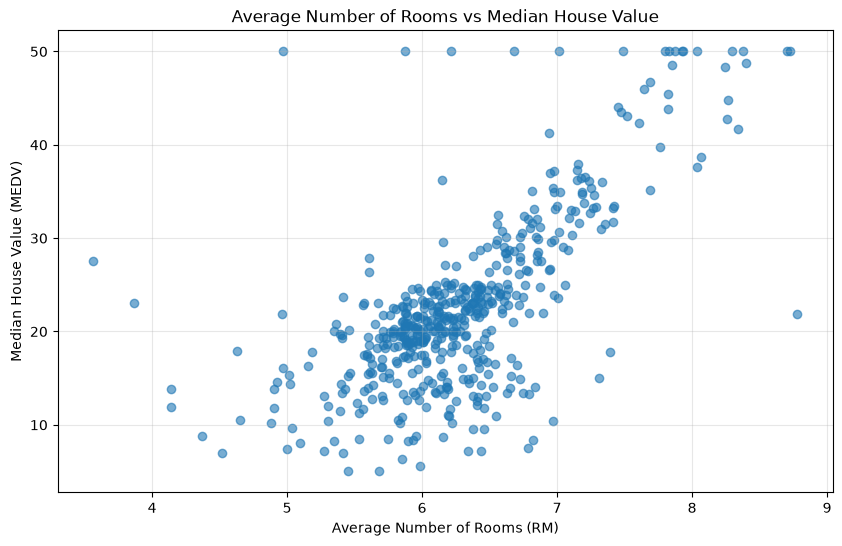

In [41]:

## RELATIONSHIP VISUALIZATION


plt.figure(figsize=(10, 6))

plt.scatter(
    regression_df["RM"],
    regression_df["MEDV"],
    alpha=0.6)

plt.title("Average Number of Rooms vs Median House Value")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.grid(True, alpha=0.3)

plt.show()

### Relationship Visualization

A scatter plot was created to examine the relationship between the average number of rooms per dwelling (`RM`) and median house value (`MEDV`) before fitting the Simple Linear Regression model.

**Observation:**

The scatter plot shows a **positive relationship** between `RM` and `MEDV`. In general, observations with a higher average number of rooms tend to have higher median house values.

However, the observations are not perfectly aligned along a straight line. There is noticeable variation in `MEDV` among observations with similar `RM` values, indicating that the number of rooms alone does not completely explain differences in house values.

Some observations also appear relatively distant from the main concentration of points, consistent with the earlier outlier assessment.

**Interpretation:**

The observed positive relationship provides a reasonable basis for investigating whether `RM` can be used as a predictor of `MEDV` using Simple Linear Regression.

The scatter plot represents an exploratory observation only; the strength and predictive performance of the relationship will be quantified after fitting and evaluating the regression model.

**Conclusion:**

The visual assessment indicates a positive association between average number of rooms and median house value. The relationship is sufficiently suitable for proceeding with Simple Linear Regression, while recognizing that other housing characteristics may also influence `MEDV`.

## STEP 12. Splitting  the Dataset into Training and Testing Sets

### 12. 1 Defining X and Y 

In [42]:
X = regression_df[["RM"]]
y = regression_df["MEDV"]

print("Predictor (X): RM")
print("Target (y): MEDV")

Predictor (X): RM
Target (y): MEDV


### 12.2 Performing the train-test split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training and testing split completed.")
print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")

Training and testing split completed.
Training observations: 404
Testing observations: 102


## 12.3 Verifying the split

In [44]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 1)
X_test shape: (102, 1)
y_train shape: (404,)
y_test shape: (102,)


### Training and Testing Split

The regression dataset was divided into training and testing subsets using an **80:20 split** with Scikit-learn's `train_test_split()` function.

**Split Configuration:**

- Training proportion: **80%**
- Testing proportion: **20%**
- Random state: **42**
- Total observations: **506**

**Result:**

- Training observations: **404**
- Testing observations: **102**
- Training predictor shape: **(404, 1)**
- Testing predictor shape: **(102, 1)**

**Observation:**

The majority of the observations were allocated to the training dataset, allowing the regression model to learn the relationship between `RM` and `MEDV`. The remaining observations were reserved as an independent testing dataset for subsequent model evaluation.

The `random_state=42` parameter was used to ensure that the same observations are selected each time the notebook is executed, making the analysis reproducible.

**Conclusion:**

The dataset was successfully divided into training and testing subsets without changing the underlying values. The training data is now ready for model fitting, while the testing data will be used later to evaluate predictive performance.

## STEP 13. Fitting the Simple Linear Regression Model

### 13.1 Creating and training the model

In [45]:
# MODEL TRAINING

# Creating the Simple Linear Regression model
linear_model = LinearRegression()

# Fitting the model using the training data
linear_model.fit(X_train, y_train)

print("Simple Linear Regression model trained successfully.")

Simple Linear Regression model trained successfully.


### 13.2 Extracting the coefficient and intercept

In [46]:
coefficient = linear_model.coef_[0]
intercept = linear_model.intercept_

print(f"Regression coefficient (slope): {coefficient:.6f}")
print(f"Regression intercept: {intercept:.6f}")

Regression coefficient (slope): 9.348301
Regression intercept: -36.246319


### Fitting the Simple Linear Regression Model

A Simple Linear Regression model was fitted using Scikit-learn's `LinearRegression()` algorithm.

The model used:

- **Independent variable (X):** `RM` — average number of rooms per dwelling
- **Dependent variable (Y):** `MEDV` — median house value
- **Training observations:** 404

**Model Results:**

- Regression coefficient (slope): **9.348301**
- Regression intercept: **-36.246319**

The fitted regression equation is:

**MEDV = -36.246319 + 9.348301 × RM**

**Interpretation of the Coefficient:**

The regression coefficient of **9.348301** indicates that a one-unit increase in the average number of rooms (`RM`) is associated with an estimated **9.35-unit increase in predicted median house value (`MEDV`)**, according to the fitted model.

**Interpretation of the Intercept:**

The intercept of **-36.246319** represents the model's predicted `MEDV` when `RM` equals zero. However, zero rooms is outside the observed range of `RM` in this dataset. Therefore, the intercept is primarily a mathematical component of the regression equation and should not be interpreted as a realistic house-value estimate.

**Observation:**

The positive regression coefficient confirms that the fitted model represents a positive relationship between the average number of rooms and predicted median house value.

**Conclusion:**

The Simple Linear Regression model was successfully fitted using the training dataset. The coefficient indicates a positive association between `RM` and `MEDV`, with approximately 9.35 units of predicted increase in `MEDV` for each one-unit increase in `RM`. Model performance will be evaluated using the testing dataset in the subsequent steps.

## STEP 14.  Generating Predictions

In [47]:
# Generating predictions using the unseen testing data
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully.")
print(f"Number of predictions: {len(y_pred)}")

Predictions generated successfully.
Number of predictions: 102


In [48]:
# Comparing actual and predicted values

prediction_comparison = pd.DataFrame({
    "Actual_MEDV": y_test.values,
    "Predicted_MEDV": y_pred})

display(prediction_comparison.head(10))

,Actual_MEDV,Predicted_MEDV
0,23.6,23.732383
1,32.4,26.929502
2,13.6,19.684568
3,22.8,20.451129
4,16.1,22.619935
5,20.0,22.451666
6,17.8,19.039536
7,14.0,21.470094
8,19.6,21.984251
9,16.8,20.095894


### Test-Set Predictions

The trained Simple Linear Regression model was used to generate predictions for the independent testing dataset.

**Prediction Results:**

- Testing observations: **102**
- Predictions generated: **102**
- Predictor used: `RM`
- Target predicted: `MEDV`

The first ten actual and predicted values were compared to provide an initial assessment of model predictions.

**Observation:**

The predicted values generally follow the scale of the actual `MEDV` values, although differences between actual and predicted values are visible for individual observations. For example, an actual value of **23.6** was predicted as approximately **23.73**, while an actual value of **32.4** was predicted as approximately **26.93**.

These individual differences demonstrate that the model does not reproduce every house value exactly. However, individual observations alone are insufficient to determine overall model performance.

**Conclusion:**

The model successfully generated predictions for all 102 previously unseen testing observations. Quantitative evaluation using R-squared and Mean Squared Error will now be performed to measure the model's overall predictive performance.

## STEP 15. Evaluating the Regression Model

In [49]:
# Calculating evaluation metrics using the testing data
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R²): {r2:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")

R-squared (R²): 0.370757
Mean Squared Error (MSE): 46.144775


In [50]:
# Calculating Root Mean Squared Error

rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

Root Mean Squared Error (RMSE): 6.792995


### Regression Model Evaluation

The performance of the Simple Linear Regression model was evaluated using the independent testing dataset. The evaluation metrics required by the project were **R-squared (R²)** and **Mean Squared Error (MSE)**. Root Mean Squared Error (RMSE) was also calculated as an additional supporting metric.

**Evaluation Results:**

- **R-squared (R²): 0.370757**
- **Mean Squared Error (MSE): 46.144775**
- **Root Mean Squared Error (RMSE): 6.792995**

**R-squared Interpretation:**

The R² value of **0.370757** indicates that approximately **37.08% of the variation in median house value (`MEDV`) in the testing dataset is explained by the average number of rooms (`RM`) through the fitted linear model.

The remaining approximately **62.92% of variation is not explained by `RM` alone**, indicating that other factors contribute to differences in median house value.

**MSE Interpretation:**

The Mean Squared Error of **46.144775** represents the average squared difference between the actual and predicted `MEDV` values in the testing dataset. Because MSE is expressed in squared units, RMSE provides an easier-to-interpret representation of prediction error.

**RMSE Interpretation:**

The RMSE of **6.792995** indicates that the model's prediction errors have a typical magnitude of approximately **6.79 `MEDV` units** based on the squared-error metric.

**Overall Observation:**

The evaluation results show that `RM` has explanatory value for `MEDV`, consistent with the positive regression coefficient of **9.348301**. However, the R² result also demonstrates that a single predictor does not account for all variation in house values.

**Conclusion:**

The Simple Linear Regression model successfully predicts `MEDV` from `RM` and provides measurable explanatory power. However, the test-set results indicate that additional housing characteristics would be needed to explain a larger proportion of the variation in median house value. For this Level 2 task, the model demonstrates the required process of training, prediction, and quantitative regression evaluation.

## STEP 16. Regression Line Visualization

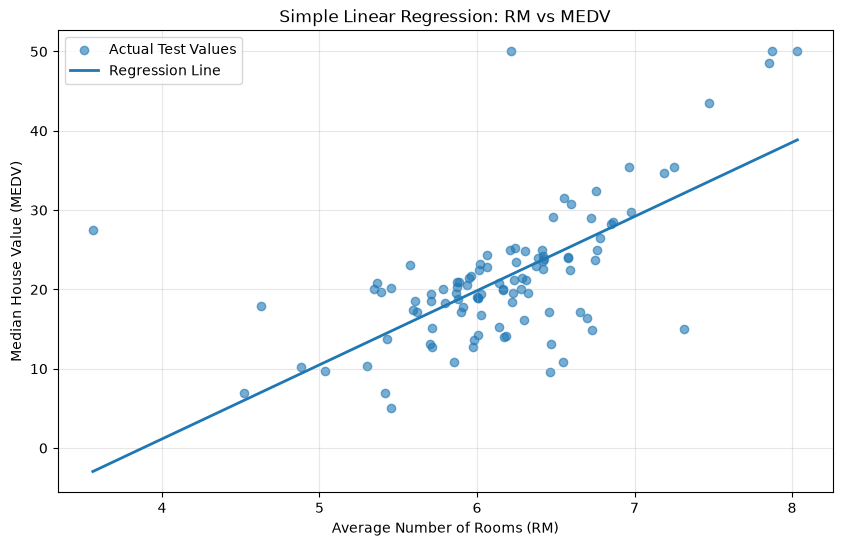

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["RM"],
    y_test,
    alpha=0.6,
    label="Actual Test Values")

# Sort values so the regression line is displayed correctly
sorted_indices = np.argsort(X_test["RM"].values)

X_test_sorted = X_test["RM"].values[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.plot(
    X_test_sorted,
    y_pred_sorted,
    linewidth=2,
    label="Regression Line")

plt.title("Simple Linear Regression: RM vs MEDV")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Regression Line Visualization

The fitted Simple Linear Regression line was plotted against the actual observations in the testing dataset to visually assess the relationship between `RM` and `MEDV`.

**Visualization Findings:**

The regression line has a positive slope, showing that predicted `MEDV` increases as the average number of rooms (`RM`) increases.

The actual test observations are distributed around the regression line rather than lying directly on it. The noticeable vertical variation between the observations and the regression line indicates that the model does not perfectly predict every house value using `RM` alone.

**Relationship to Model Evaluation:**

The visual pattern is consistent with the previously calculated **R² of 0.370757**. The model explains a portion of the variation in `MEDV`, while substantial variation remains unexplained by the single predictor.

The visualization also agrees with the positive regression coefficient of **9.348301**, which indicates a positive relationship between `RM` and predicted `MEDV`.

**Conclusion:**

The regression visualization confirms a positive linear relationship between average number of rooms and median house value. However, the spread of the observations around the fitted line demonstrates that `RM` alone does not fully account for differences in `MEDV`. The visualization therefore provides a graphical representation of the model's statistical results.

# Regression Analysis

## Summary of Analysis

A Simple Linear Regression analysis was performed using the Boston Housing dataset to investigate whether the average number of rooms per dwelling (`RM`) could be used to predict median house value (`MEDV`).

Before modelling, the dataset was examined for data-quality issues. The dataset contained **506 observations and 14 variables**. The assessment identified:

- **0 missing values**
- **0 duplicate records**
- **0 non-numeric values**
- **0 infinite values**

Potential outliers were assessed using the Interquartile Range (IQR) method. Several statistically unusual observations were identified across some variables; however, no observations were removed because there was no evidence that these values represented data-entry errors or invalid records.

For the regression analysis, `RM` was selected as the independent variable and `MEDV` as the dependent variable.

The dataset was divided into:

- **404 training observations (80%)**
- **102 testing observations (20%)**

A Simple Linear Regression model was then fitted using Scikit-learn's `LinearRegression()` algorithm.

## Regression Model Results

The fitted regression equation was:

**MEDV = -36.246319 + 9.348301 × RM**

The regression coefficient (slope) was **9.348301**, indicating that a one-unit increase in the average number of rooms (`RM`) was associated with an estimated **9.35-unit increase in predicted median house value (`MEDV`)**, according to the fitted model.

The intercept was **-36.246319**. Since `RM = 0` is outside the observed range of the dataset, the intercept is primarily a mathematical component of the regression equation rather than a practically meaningful house-value estimate.

## Model Evaluation

The trained model generated predictions for all **102 observations** in the testing dataset.

The evaluation results were:

| Metric | Result |
|---|---:|
| R-squared (R²) | **0.370757** |
| Mean Squared Error (MSE) | **46.144775** |
| Root Mean Squared Error (RMSE) | **6.792995** |

The **R² value of 0.370757** indicates that approximately **37.08% of the variation in `MEDV` within the testing dataset is explained by `RM` through the fitted linear regression model**.

The **MSE of 46.144775** represents the average squared prediction error.

The **RMSE of 6.792995** indicates that the prediction errors have a typical magnitude of approximately **6.79 MEDV units** under the squared-error-based measure.

## Visualization Findings

The scatter plot and fitted regression line showed a **positive linear relationship** between average number of rooms and median house value. As `RM` increased, predicted `MEDV` generally increased.

However, the actual observations showed noticeable dispersion around the regression line. This indicates that `RM` alone does not account for all differences in house values.

The visual result is consistent with the model's R² value of **0.370757**, which indicates that a substantial proportion of the variation in `MEDV` remains unexplained by this single predictor.

## Conclusion

The Simple Linear Regression analysis successfully demonstrated the relationship between average number of rooms (`RM`) and median house value (`MEDV`) using the required Scikit-learn modelling approach.

The model identified a **positive relationship**, with a regression coefficient of **9.348301**. On the testing dataset, the model produced an **R² of 0.370757** and an **MSE of 46.144775**.

These results show that `RM` provides measurable explanatory information about `MEDV`, while also demonstrating that a single housing characteristic does not explain the full variation in house values.

Overall, the analysis successfully fulfilled the objectives of the Level 2 Task 1 assignment by:

1. Splitting the dataset into training and testing sets.
2. Fitting a Simple Linear Regression model using Scikit-learn.
3. Interpreting the regression coefficient and intercept.
4. Generating predictions on previously unseen testing observations.
5. Evaluating the model using R² and MSE.
6. Visualizing and interpreting the relationship between the predictor and target variables.